### Level 3 (Advanced): Task 2 – Support Vector Machine (SVM)
### Objective: Binary classification with different kernels and decision boundary visualization.

#### Decision-Making: I used the Breast Cancer dataset. SVMs are particularly powerful for medical diagnosis because they maximize the "margin" between classes (Malignant vs. Benign), providing a robust safety buffer for critical predictions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

In [2]:
# Load Data (Using 2 features for visualization purposes)
cancer = datasets.load_breast_cancer()
X = cancer.data[:, :2] # Taking first two features: Mean Radius and Mean Texture
y = cancer.target

In [3]:
# Train - test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Scaling is crucial for SVM performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
# Compare Kernels (Linear vs RBF)
kernels = ['linear', 'rbf']
for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True)
    svm.fit(X_train, y_train)
    
    y_pred = svm.predict(X_test)
    auc = roc_auc_score(y_test, svm.predict_proba(X_test)[:, 1])
    print(f"Kernel: {kernel} | Accuracy: {accuracy_score(y_test, y_pred):.4f} | AUC: {auc:.4f}")

Kernel: linear | Accuracy: 0.9006 | AUC: 0.9750
Kernel: rbf | Accuracy: 0.9064 | AUC: 0.9613


In [5]:
# Visualize Decision Boundary (using RBF)
best_svm = SVC(kernel='rbf').fit(X_train, y_train)

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = best_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

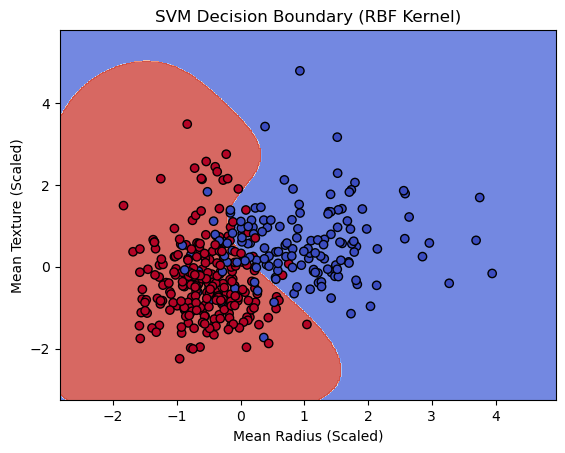

In [6]:
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title("SVM Decision Boundary (RBF Kernel)")
plt.xlabel("Mean Radius (Scaled)")
plt.ylabel("Mean Texture (Scaled)")
plt.show()